# Notebook 4: Policy Function Iteration

In this notebook, we will consider an alternative algorithm to solve for the value function. In comparison to standard VFI, we will use the optimal policy to increase the speed at which we converge towards the fixed point.

In [1]:
using LinearAlgebra
using LaTeXStrings
using Plots;

In [2]:
# Rouwenhorst's method to approximate AR(1) processes.
# credit@QuantEcon
function rouwenhorst(N::Integer, ρ::Real, σ::Real, μ::Real=0.0)
    σ_y = σ / sqrt(1-ρ^2)
    p  = (1+ρ)/2
    ψ = sqrt(N-1) * σ_y
    m = μ / (1 - ρ)

    state_values, p = _rouwenhorst(p, p, m, ψ, N)
    return p, [state_values;]
end

function _rouwenhorst(p::Real, q::Real, m::Real, Δ::Real, n::Integer)
    if n == 2
        return [m-Δ, m+Δ],  [p 1-p; 1-q q]
    else
        _, θ_nm1 = _rouwenhorst(p, q, m, Δ, n-1)
        θN = p    *[θ_nm1 zeros(n-1, 1); zeros(1, n)] +
             (1-p)*[zeros(n-1, 1) θ_nm1; zeros(1, n)] +
             q    *[zeros(1, n); zeros(n-1, 1) θ_nm1] +
             (1-q)*[zeros(1, n); θ_nm1 zeros(n-1, 1)]

        θN[2:end-1, :] ./= 2

        return range(m-Δ, stop=m+Δ, length=n), θN
    end
end;

In [3]:
# Structural parameters
β = 0.99     #discount rate
δ = 0.025    #depreciation rate
α = 0.33     #capital share
γ = 1.       #EIS
Z = 1.       #mean of technology in levels
ρ = 0.9      #persistence of technology
σ = 0.008;   #SD of technological shocks
# Steady-state values
kstat = ((1-β*(1-δ))/(Z*β*α))^(1/(α-1))
cstat = Z*kstat^α - δ*kstat;

In [6]:
# Discretize the stochastic process for technology
nz=7                                #number of discretized states
Π,z_vec=rouwenhorst(nz,ρ,σ,log(Z));
# Discretize capital
k_low  = 0.8*kstat                  #lowest value for capital
k_high = 1.2*kstat                  #highest value for capital
nk     = 501                        #number of grid points
dk     = (k_high-k_low)/(nk - 1)    #step size
k_vec  = [k_low:dk:k_high;]         #capital vector
ks     = k_low:dk:k_high;           #range for plots

In [7]:
# Compute utility for all point in the state space
k0 = ones(nk,1) *k_vec'         #capital today (state)
k1 = k_vec*ones(1,nk)           #capital for the next period
c = cat([exp.(z_vec[i]).* k0.^α .- k1 .+ (1-δ) .* k0 for i=1:nz]..., dims=3) #consumption over all states and controls
c[findall(x->x<0,c)] .= 0.;      #set negative consumption values to zero
#period utility
if γ == 1
    u = log.(c)
else
    u = (c.^(1-γ).-1)/(1-γ)
end;

In [12]:
# VFI algorithm
tol  = 1e-8                #tolerance for the fixed-point of V
iter = 0                   #iteration counter
dist = [10e6]              #initialize a measure of distance between iterates of V
V    = zeros(nk,nz)        #initial guess for the value function
P    = zeros(nk,nz);       #initialize a vector for the policy
# Solve for the fixed point
elapsed_time = @elapsed begin
while dist[end] > tol

    EV = V * Π' #expected continuation value
    W  = u .+ β.*repeat(reshape(EV,nk,1,nz),1,nk, 1)

    TV, TP = findmax(W,dims=1)
    #maximize for a given stock of capital and state of technology
    #(i.e., for each column of W, finds the maximum over rows.)

    TV = TV[1,:,:]
    TP = getindex.(TP[1,:,:],1)

    dist = [dist; maximum(abs.(TV - V))]

    #update policy and value functions
    V  = TV
    P  = TP

    iter+=1

end
end
dist=dist[2:end];V1=V
println("Value Function Iteration converged after $iter iterations in $elapsed_time sec.")

Value Function Iteration converged after 1814 iterations in 11.902473416 sec.


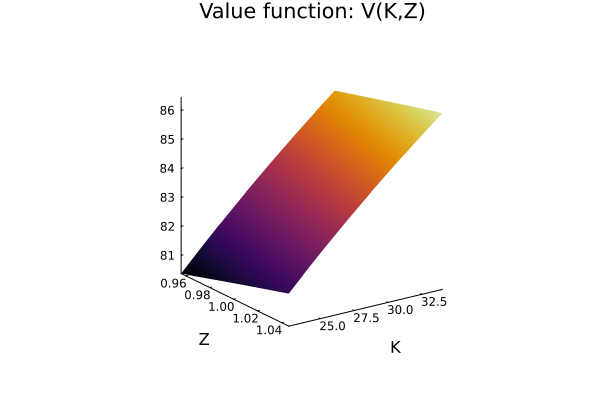

In [9]:
surface(exp.(z_vec), k_vec, V;
    xlabel="Z",
    ylabel="K",
    zlabel="",
    title="Value function: V(K,Z)",
    grid=false,
    camera=(55, 20),
    colorbar=false)

In [13]:
# Policy Function Iteration algorithm
tol  = 1e-8                #tolerance for the fixed-point of V
iter = 0                   #iteration counter
dist = [10e6]              #initialize a measure of distance between iterates of V
V    = zeros(nk,nz)        #initial guess for the value function
P    = ones(Int,nk,nz);    #initialize policy (indices for k')
#Solve for the fixed point
elapsed_time = @elapsed begin
while dist[end] > tol

    # Step 1: Policy Evaluation
    # Compute utility under current policy
    u_policy = zeros(nk,nz)
    for i = 1:nz
        for j = 1:nk
            u_policy[j, i] = u[P[j, i], j, i]
        end
    end

    V_policy = copy(V)

    # Solve a Linear System of equations
    # Build transition matrix under current policy
    # V = u_policy + β * T_policy * V
    # Rearranging: (I - β * T_policy) * V = u_policy
    # Where T_policy[state_today, state_tomorrow] gives prob of transition

    # Flatten to vector form (stack states)
    n_states = nk * nz
    u_vec = vec(u_policy)  # Convert to vector (column-major order)

    # Build policy-specific transition matrix
    T_policy = zeros(n_states, n_states)
        for i = 1:nz  # current productivity
            for j = 1:nk  # current capital
                current_idx = (i-1)*nk + j
                k_prime_idx = P[j, i]  # chosen capital tomorrow

                for i_next = 1:nz  # next productivity
                    next_idx = (i_next-1)*nk + k_prime_idx
                    T_policy[current_idx, next_idx] = Π[i, i_next]
                end
            end
        end

    # Solve linear system: V = (I - β*T_policy)^(-1) * u_policy
    V_vec = (I - β * T_policy) \ u_vec
    V_policy = reshape(V_vec, nk, nz)
 

    # Step 2: Policy Improvement
    EV = V_policy * Π'
    W = u .+ β.*repeat(reshape(EV, nk, 1, nz), 1, nk, 1)
    TV, TP = findmax(W, dims=1)
    # maximize over rows (k' choices) for each column (k state)

    TV = TV[1, :, :]
    TP = getindex.(TP[1, :, :], 1)

    # Check convergence
    dist = [dist; maximum(abs.(TV - V_policy))]

    # Update policy and value functions
    V = TV
    P = TP
    iter += 1
end
end
dist = dist[2:end];V2=V
println("Policy Iteration converged after $iter iterations in $elapsed_time sec.")

Policy Iteration converged after 16 iterations in 3.38110325 sec.


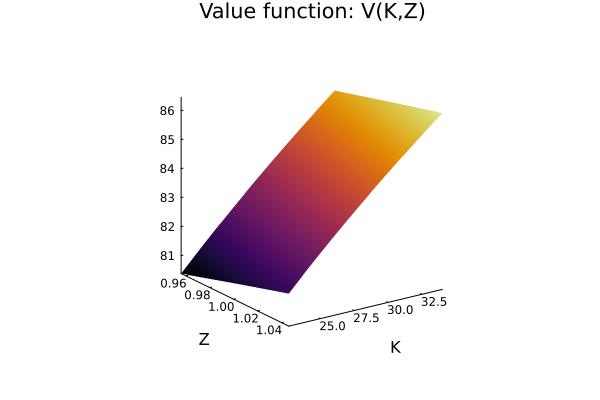

In [14]:
surface(exp.(z_vec), k_vec, V;
    xlabel="Z",
    ylabel="K",
    zlabel="",
    title="Value function: V(K,Z)",
    grid=false,
    camera=(55, 20),
    colorbar=false)

In [15]:
# Compare results
maximum(abs.(V2-V1)) 

9.816136525842012e-7